# GridFM on IEEE-118: N-1 contingency screening

This notebook trains a GridFM power-flow model from scratch on a slice of the
[`gridfm/pf_small_case118_ieee`](https://huggingface.co/datasets/gridfm/pf_small_case118_ieee)
dataset and then uses it for **N-1 contingency screening** — the operational question
*"if any single line trips, does the grid violate a limit?"*

It runs end-to-end in **9–11.5 minutes on Apple Silicon (MPS)**, nearly all of it training. That is
a demo budget, not a reference training recipe, so the model is deliberately undertrained. We report
what it actually achieves, including where it loses to a trivial DC baseline, and diagnose why.

> Exact figures move between runs: MPS kernels are not bit-deterministic, so `seed: 0` pins the data
> split and initialisation but not the arithmetic. Two runs of this notebook gave masked-bus Vm RMSE
> 0.0028 and 0.0035 p.u., and the same 15 epochs took 30 and 44 s/epoch on the same laptop. The
> qualitative conclusions below are stable across a re-run; the individual numbers are not, and the
> summary at the end quotes spreads rather than point values for that reason.

**What you will see**

1. Real learning: masked-bus voltage magnitude RMSE ~0.003 p.u., a ~120x improvement
   on the untrained model.
2. **Voltage-violation screening** — the model's genuine strength here (F1 ~0.85).
3. **Thermal/overload screening** — where a ~7 degree residual angle error hurts, and a
   diagnostic isolating exactly which predicted quantity is responsible.
4. An honest speed comparison against the AC solver.

### Prerequisite: the dataset

The slice below is cut from a local copy of the full dataset. Download it once with:

```python
from huggingface_hub import snapshot_download
snapshot_download(repo_id="gridfm/pf_small_case118_ieee", repo_type="dataset",
                  local_dir="<DATA_ROOT>/pf_small_case118_ieee/raw", max_workers=16)
```

The full dataset is ~7 GB (219,103 scenarios). We only read the first 25 of its
`scenario_partition=*` directories, so you can also fetch just those with
`allow_patterns=["*scenario_partition=[0-9]/*", "*scenario_partition=1[0-9]/*", "*scenario_partition=2[0-4]/*"]`.
Set `DATA_ROOT` below to wherever it landed.

In [10]:
import os
import pathlib
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import lightning.pytorch as pl
from torch_geometric.loader import DataLoader

from gridfm_graphkit.datasets.hetero_powergrid_datamodule import LitGridHeteroDataModule
from gridfm_graphkit.io.param_handler import NestedNamespace, get_task

# --- paths (absolute, so a later chdir into the artifacts dir cannot break them) -----------
REPO = pathlib.Path.cwd().parents[1]  # examples/notebooks -> repo root
DATA_ROOT = REPO / "data"  # where the HF download lives
SRC = DATA_ROOT / "pf_small_case118_ieee" / "raw"  # full dataset
NETWORK = "nb_pf_case118"  # name referenced by the config
DST = DATA_ROOT / NETWORK / "raw"  # the slice we build
CONFIG = REPO / "examples" / "config" / "HGNS_PF_case118_tutorial.yaml"
ARTIFACTS = DATA_ROOT / "nb_out_pf"  # plots/logs (inside gitignored data/)
ARTIFACTS.mkdir(parents=True, exist_ok=True)

N_PARTITIONS = 25  # 200 scenarios each -> 5,000 scenarios
# The physics analysis in sections 7-9 rebuilds an admittance matrix per scenario in a Python
# loop, which costs ~0.1 s each. 200 of the ~500 test scenarios keeps that under a minute while
# still giving a few hundred true overload events to score against. Raise it if you have time.
N_ANALYSIS = 200
SN_MVA = 100.0  # system power base: the MVA value that "1.0 per unit" refers to
timings = {}  # phase -> seconds, printed as a breakdown at the end
print("repo:", REPO)
print("MPS available:", torch.backends.mps.is_available())

repo: /Users/pao/Documents/IBM/gridfm-graphkit
MPS available: True


## 1. Build a 5,000-scenario slice

`HeteroGridDatasetDisk.process()` reads the **whole** raw directory into pandas regardless of
`data.scenarios`, so pointing it at the full 219k-scenario dataset would need tens of GB of RAM.
We therefore physically cut a smaller raw directory first.

Partition `p` holds scenarios `[200p, 200p+199]`, so taking partitions `0..24` gives contiguous
scenario ids starting at 0 — which is exactly what `process()` asserts. We write one consolidated
parquet per table (not partitioned), which `process()` reads happily.

In [11]:
t0 = time.time()
if (DST / "bus_data.parquet").exists():
    print("slice already present, skipping")
else:
    assert SRC.exists(), f"dataset not found at {SRC} - see the download snippet above"
    DST.mkdir(parents=True, exist_ok=True)
    # Three tables per scenario: bus (loads, voltages, limits), gen (dispatch, cost, limits) and
    # branch (topology, impedances, ratings, flows). Each is a Hive-partitioned directory upstream,
    # so we read the first N_PARTITIONS subdirectories and concatenate them into one flat file.
    for table in ["bus", "gen", "branch"]:
        parts = [
            pd.read_parquet(SRC / f"{table}_data.parquet" / f"scenario_partition={p}")
            for p in range(N_PARTITIONS)
        ]
        # kind="stable" keeps the within-scenario row order the generator wrote, which is what
        # `process()` relies on when it reshapes rows into per-scenario graphs.
        df = pd.concat(parts, ignore_index=True).sort_values("scenario", kind="stable")
        df.to_parquet(DST / f"{table}_data.parquet", index=False)
        print(
            f"  {table:7s} {len(df):>7d} rows, scenarios {df.scenario.min()}-{df.scenario.max()}"
        )
timings["slice"] = time.time() - t0

# Keep bus and branch tables in memory: sections 6-9 need the raw columns (voltage limits, line
# ratings, the shipped DC solution) that the model never sees and the prediction table therefore
# does not carry.
bus_raw = pd.read_parquet(DST / "bus_data.parquet")
branch_raw = pd.read_parquet(DST / "branch_data.parquet")
print(
    f"\nslice built in {timings['slice']:.1f}s | "
    f"{bus_raw.scenario.nunique()} scenarios, "
    f"{bus_raw.load_scenario_idx.nunique()} distinct load scenarios, "
    f"{sum(f.stat().st_size for f in DST.glob('*.parquet')) / 1e6:.0f} MB"
)

slice already present, skipping

slice built in 0.0s | 5000 scenarios, 228 distinct load scenarios, 71 MB


> **Note on the split.** The config uses `split_by_load_scenario_idx: true`, which splits on
> *distinct load scenarios* so that topology variants of the same load never straddle the
> train/test boundary. With `val_ratio: 0.1` you need at least 10 distinct load scenarios or the
> validation set comes out empty and training aborts on a missing monitor metric. Our slice has
> 228, so this is fine — but it is why the slice cannot be made arbitrarily small.

## 2. Set up the data module and model

In [12]:
import yaml

t0 = time.time()
# NestedNamespace turns the YAML dict into a recursive argparse.Namespace, which is how the whole
# library reads config: `args.training.batch_size`, not `args["training"]["batch_size"]`.
args = NestedNamespace(**yaml.safe_load(open(CONFIG)))
pl.seed_everything(args.seed, workers=True)

# The datamodule is the orchestrator. `setup("fit")` does three expensive things:
#   1. HeteroGridDatasetDisk.process() converts the raw parquet into one PyG HeteroData .pt file
#      per scenario under data/<network>/processed/ (skipped if processed_raw_files.done exists);
#   2. it splits into train/val/test -- here by distinct load scenario, see the note above;
#   3. it *fits* the normalizer on the training split. Normalization is applied lazily inside
#      __getitem__, so the stats have to exist before the first batch is drawn.
datamodule = LitGridHeteroDataModule(args, str(DATA_ROOT))
datamodule.setup("fit")
timings["setup"] = time.time() - t0

# get_task resolves `task.task_name` ("PowerFlow") through the TASK registry and builds the
# LightningModule: model + loss + metrics, all named by strings in the YAML. The normalizers are
# handed in because the task de-normalises predictions before computing physical-unit metrics.
task = get_task(args, datamodule.data_normalizers)
n_params = sum(p.numel() for p in task.model.parameters())
print(f"setup: {timings['setup']:.1f}s")
print(
    f"train/val/test scenarios: {len(datamodule.train_datasets[0])} / "
    f"{len(datamodule.val_datasets[0])} / {len(datamodule.test_datasets[0])}"
)
print(
    f"model: {args.model.type}, {args.model.num_layers} layers, "
    f"hidden {args.model.hidden_size}, {n_params / 1e6:.1f}M parameters"
)

Seed set to 0


Fitting normalizer on train set (4032 scenarios)
setup: 0.1s
train/val/test scenarios: 4032 / 484 / 484
model: GNS_heterogeneous, 12 layers, hidden 48, 20.1M parameters


A `Trainer` here **must** be given a real logger. `BaseTask.on_fit_start` writes the normalizer
statistics to `self.logger.save_dir`, so `logger=False` raises
`AttributeError: 'NoneType' object has no attribute 'save_dir'`. A `CSVLogger` is enough and keeps
everything on disk next to the other artifacts.

In [13]:
def make_trainer(**kw):
    """A Trainer configured the way this notebook needs it.

    `accelerator`/`devices` come from the config, so `accelerator: auto` selects MPS here.
    `enable_checkpointing=False` because we keep the trained model in memory -- nothing below
    reloads it from disk, and .ckpt files for a 20M-parameter model add up fast.
    """
    return pl.Trainer(
        accelerator=args.training.accelerator,
        devices=args.training.devices,
        logger=pl.loggers.CSVLogger(str(ARTIFACTS), name="pf"),
        enable_checkpointing=False,
        **kw,
    )


def prediction_table(predictions):
    """Flatten pf_task.predict_step outputs into one tidy DataFrame, one row per bus.

    `trainer.predict` returns a list holding whatever `predict_step` returned, one entry per
    batch. For `pf_task` that is a dict of flat tensors, already de-normalised into physical
    units, with these columns:

      Vm_pred, Va_pred      the model's output
      Vm_target, Va_target  the AC solver's answer (ground truth)
      PQ, PV, REF           one-hot bus type -- see `bus_voltages` below
      scenario, bus         identifiers, so rows can be joined back to the raw parquet

    Two mechanical wrinkles: Lightning nests the list one level deeper when there are multiple
    dataloaders (hence the `predictions[0]` unwrap), and some entries come back shaped (N, 1)
    rather than (N,) (hence `.ravel()`).
    """
    batches = predictions[0] if isinstance(predictions[0], list) else predictions
    return pd.concat(
        [
            pd.DataFrame({k: np.asarray(v).ravel() for k, v in b.items()})
            for b in batches
        ],
        ignore_index=True,
    )


def bus_voltages(table):
    """Vm (p.u.) and Va (rad) with the quantities a power flow already knows clamped to truth.

    A power flow is a *partly specified* problem, and which quantities are given depends on the
    bus type -- this is the one piece of domain convention the rest of the notebook rests on:

      PQ  ("load" bus)       real and reactive demand are given; both Vm and Va are unknown,
                             so these are the buses where the model is genuinely predicting.
      PV  ("generator" bus)  real power and voltage *magnitude* are given (the generator's
                             regulator holds Vm at setpoint); only Va is unknown.
      REF ("slack" bus)      both Vm and Va are given. It is the angle reference -- the zero
                             that every other bus angle is measured against -- and it also
                             absorbs whatever power the rest of the system does not balance.

    So Vm at PV/REF buses and Va at the REF bus are *inputs*, not predictions. The model emits a
    number for every bus regardless, and scoring those against "truth" would be scoring it on
    what it was told. We overwrite them with the given values, exactly as a solver would. That
    also matters physically: the branch flows computed in section 7 are only meaningful if the
    known voltages are the real ones.

    Units, and the easiest mistake in this notebook:
      * Vm is per-unit -- 1.0 means the bus's own nominal kV, so 0.94-1.06 p.u. is the usual
        operating band regardless of whether the bus is 138 kV or 345 kV.
      * Va out of the prediction table is in RADIANS: the normalizer multiplies degrees by
        pi/180 on the way in and does not undo it on the way out.
      * Va in the raw parquet (`bus_raw.Va`, `bus_raw.Va_dc`) is in DEGREES.
    Every conversion below is marked with a comment for that reason.
    """
    vm = table["Vm_pred"].to_numpy().copy()  # copy: we are about to overwrite entries
    va = table["Va_pred"].to_numpy().copy()
    known_vm = (table["PV"].to_numpy() == 1) | (table["REF"].to_numpy() == 1)
    is_ref = table["REF"].to_numpy() == 1
    vm[known_vm] = table["Vm_target"].to_numpy()[known_vm]
    va[is_ref] = table["Va_target"].to_numpy()[is_ref]
    return vm, va

## 3. Baseline: the same model before any training

Every accuracy number below should be read against this. It is the same architecture with freshly
initialised weights, so it isolates what training actually bought.

In [14]:
# Same architecture, same normalizers, freshly initialised weights -- get_task builds a new model
# every call, so this is an independent instance and training `task` below does not touch it.
untrained = get_task(args, datamodule.data_normalizers)
tbl_untrained = prediction_table(
    make_trainer(enable_progress_bar=False).predict(untrained, datamodule=datamodule)
)
vm_u, va_u = bus_voltages(tbl_untrained)

# Score each quantity only where it was actually predicted -- and note the two masks are NOT the
# same, which follows straight from the bus-type table in `bus_voltages`:
#   * Vm is given at PV and REF buses (54 of 118), so averaging over all buses would dilute the
#     error with rows `bus_voltages` just clamped to truth, i.e. exact by construction.
#   * Va is given only at the single REF bus, so `pq` would be wrong in the *other* direction: it
#     would throw away the ~53 PV buses where Va is a genuine prediction. Hence `not_ref`.
# Both masks are read per row rather than from a fixed bus list, because the N-1 topology
# perturbation takes generators out of service, which turns a PV bus into a PQ one.
pq = tbl_untrained["PQ"].to_numpy() == 1
not_ref = tbl_untrained["REF"].to_numpy() == 0
mae_vm_untrained = np.abs(vm_u - tbl_untrained["Vm_target"].to_numpy())[pq].mean()
mae_va_untrained = np.abs(va_u - tbl_untrained["Va_target"].to_numpy())[not_ref].mean()
print(f"untrained  |dVm| at PQ buses    = {mae_vm_untrained:.5f} p.u.")
print(
    f"untrained  |dVa| at PQ+PV buses = {mae_va_untrained:.5f} rad "
    f"({np.rad2deg(mae_va_untrained):.2f} deg)"
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/pao/Documents/IBM/gridfm-graphkit/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/pao/Documents/IBM/gridfm-graphkit/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Setup already done for stage=TrainerFn.PREDICTING, skipping...
untrained  |dVm| at PQ buses    = 0.19901 p.u.
untrained  |dVa| at PQ+PV buses = 0.15133 rad (8.67 deg)


## 4. Train

15 epochs at batch 64 — 30–44 s/epoch on MPS depending on machine load, so 8–11 minutes. The
validation loss is still falling when we stop (see the curve below), so this model is undertrained on
purpose to respect the ~10 minute budget.

In [15]:
t0 = time.time()
trainer = make_trainer(max_epochs=args.training.epochs, log_every_n_steps=50)
trainer.fit(task, datamodule=datamodule)
timings["train"] = time.time() - t0
print(
    f"\ntrained {args.training.epochs} epochs in {timings['train']:.0f}s "
    f"({timings['train'] / args.training.epochs:.1f}s/epoch)"
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Setup already done for stage=TrainerFn.FITTING, skipping...


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ GNS_heterogeneous │ 20.1 M │ train │     0 │
│ 1 │ loss_fn │ MixedLoss         │      0 │ train │     0 │
└───┴─────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 20.1 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 20.1 M                                                                                               
Total estimated model params size (MB): 80.277                                                                     
Modules in train mode: 353                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/Users/pao/Documents/IBM/gridfm-graphkit/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/da
ta_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

creating train dataloader for rank  not distributed

/Users/pao/Documents/IBM/gridfm-graphkit/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/da
ta_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider 
increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=15` reached.



trained 15 epochs in 441s (29.4s/epoch)


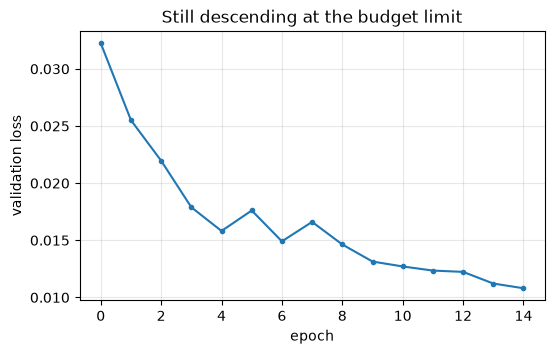

       Validation loss
epoch                 
12             0.01223
13             0.01121
14             0.01080


In [16]:
# The CSVLogger writes one row per logging call, so a column is NaN on rows logged by a different
# hook. Hence: drop the NaNs, then take the last row per epoch (there is one validation value per
# epoch, but several training rows). Note the capitalisation -- the task logs "Validation loss"
# with a lowercase L and "Training Loss" with an uppercase one.
curve = pd.read_csv(pathlib.Path(trainer.logger.log_dir) / "metrics.csv")
curve = curve[["epoch", "Validation loss"]].dropna().groupby("epoch").last()
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(curve.index, curve["Validation loss"], marker="o", ms=3)
ax.set(
    xlabel="epoch",
    ylabel="validation loss",
    title="Still descending at the budget limit",
)
ax.grid(alpha=0.3)
plt.show()
print(curve.tail(3).to_string(float_format=lambda x: f"{x:.5f}"))

## 5. Test metrics and the learning check

`pf_task` logs its test metrics with `logger=False`, so they do **not** come back from
`trainer.test()`. They are written as CSVs under the logger's `save_dir` instead.

In [17]:
trainer.test(task, datamodule=datamodule)
# The returned dict is empty by design (the task logs with logger=False), so read the CSVs the task
# wrote instead. `RMSE` is per-quantity error at masked buses; `metrics` holds the task's own
# aggregate numbers. Both are written under <logger save_dir>/test/, named after the network.
for name in ["RMSE", "metrics"]:
    path = ARTIFACTS / "test" / f"{NETWORK}_{name}.csv"
    if path.exists():
        print(f"--- {name} ---")
        print(pd.read_csv(path).to_string(index=False))

Output()

Setup already done for stage=TrainerFn.TESTING, skipping...


/Users/pao/Documents/IBM/gridfm-graphkit/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/pao/Documents/IBM/gridfm-graphkit/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


/Users/pao/Documents/IBM/gridfm-graphkit/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3036: 
RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]

/Users/pao/Documents/IBM/gridfm-graphkit/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3036: 
RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]

/Users/pao/Documents/IBM/gridfm-graphkit/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3036: 
RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]

--- RMSE ---
  Metric    Pg (MW)  Qg (MVar)  Vm (p.u.)  Va (radians)
 RMSE-PQ   0.000000   0.000000   0.002978      0.104567
 RMSE-PV   0.000000  10.158446   0.000000      0.101515
RMSE-REF 221.550132 133.234162   0.022502      0.000000
--- metrics ---
                   Metric      Value
    Avg. active res. (MW)   4.265235
Avg. reactive res. (MVar)   1.032269
                 PBE Mean   4.668443
                  PBE Max 164.286484


In [18]:
t0 = time.time()
# `tbl` is the object the whole second half of the notebook works from: one row per (scenario, bus)
# on the held-out test split, with predictions and ground truth side by side.
tbl = prediction_table(
    make_trainer(enable_progress_bar=False).predict(task, datamodule=datamodule)
)
timings["predict"] = time.time() - t0
vm_pred, va_pred = bus_voltages(tbl)
vm_true = tbl["Vm_target"].to_numpy()
va_true = tbl["Va_target"].to_numpy()  # RADIANS, like Va_pred
# The two masks from section 3, for the same reason: Vm is a given input at PV and REF buses, Va
# only at the single REF bus, so each quantity is scored exactly where the model had to predict it.
pq = tbl["PQ"].to_numpy() == 1
not_ref = tbl["REF"].to_numpy() == 0

# Same two metrics as the untrained baseline, so the improvement column is an apples-to-apples ratio.
mae_vm = np.abs(vm_pred - vm_true)[pq].mean()
mae_va = np.abs(va_pred - va_true)[not_ref].mean()
print(f"{'':12s} {'|dVm| at PQ (p.u.)':>20s} {'|dVa| PQ+PV (deg)':>19s}")
print(
    f"{'untrained':12s} {mae_vm_untrained:>20.5f} {np.rad2deg(mae_va_untrained):>19.2f}"
)
print(f"{'trained':12s} {mae_vm:>20.5f} {np.rad2deg(mae_va):>19.2f}")
print(
    f"{'improvement':12s} {mae_vm_untrained / mae_vm:>19.1f}x "
    f"{mae_va_untrained / mae_va:>18.1f}x"
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/pao/Documents/IBM/gridfm-graphkit/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/pao/Documents/IBM/gridfm-graphkit/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Setup already done for stage=TrainerFn.PREDICTING, skipping...
               |dVm| at PQ (p.u.)   |dVa| PQ+PV (deg)
untrained                 0.19901                8.67
trained                   0.00170                4.25
improvement                117.2x                2.0x


## 6. Voltage-violation screening

The first real security question: does any bus leave its `[min_vm_pu, max_vm_pu]` band
(0.94–1.06 p.u. here)? This is where the model is strong, because voltage *magnitude* is the
quantity it learns well.

The limits come from the **raw** parquet, not from the prediction table: the power-flow mask zeroes
`Vm_min`/`Vm_max` in the model input, so those table columns are all zero.

`compute_cm_metrics` is shared with the overload analysis and hard-codes the word "overloadings"
in its printout; here those lines refer to voltage violations.

voltage band [0.94, 1.06] p.u. | 2.68% of 57112 bus-cases truly violate

Accuracy: 0.988
Confusion Matrix:
TP: 1420, FP: 549, TN: 55033, FN: 110
GridFM
TPR: 0.928 (percentage of overloadings correctly predicted)
FPR: 0.010 (percentage of non-overloadings predicted as overloadings)
TNR: 0.99
FNR: 0.07

F1 = 0.812


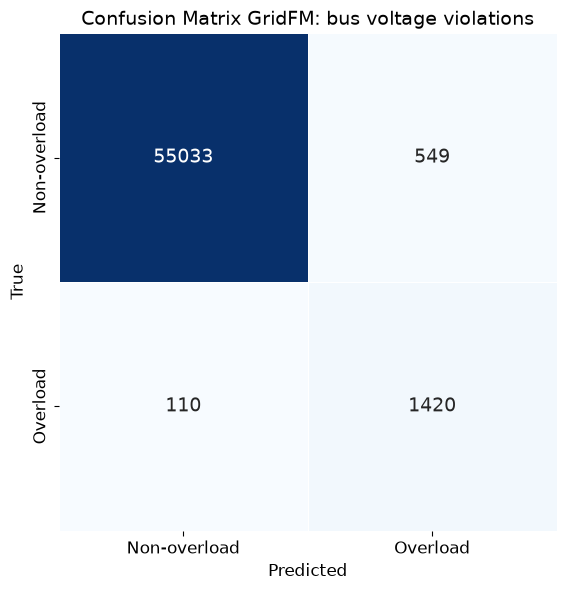

In [19]:
from gridfm_graphkit.utils.utils import compute_cm_metrics
from gridfm_graphkit.utils.visualization import (
    plot_cm,
    plot_loading_predictions,
    plot_mass_correlation_density,
    plot_mass_correlation_density_voltage,
)

# the plotting helpers save PNG/TXT into the CWD; keep them out of the repo
os.chdir(ARTIFACTS)

# Attach each bus's voltage limits to the prediction table. (scenario, bus) is the unique key on
# both sides -- limits vary per scenario in principle, so we join rather than broadcast a constant.
limits = bus_raw.set_index(["scenario", "bus"])[["min_vm_pu", "max_vm_pu"]]
volt = tbl.set_index(["scenario", "bus"]).join(limits).reset_index()
# Re-derive the clamped voltages on the joined frame: the join reordered rows, so vm_pred from the
# earlier cell no longer lines up. Cheap to recompute, and it cannot silently misalign.
vm_p, _ = bus_voltages(volt)
lo = volt["min_vm_pu"].to_numpy()
hi = volt["max_vm_pu"].to_numpy()
vm_t = volt["Vm_target"].to_numpy()

# The screening decision itself: one boolean per (scenario, bus), true if the bus is outside its
# band. We compare the model's verdict against the AC solver's verdict, not against the voltages.
viol_true = (vm_t < lo) | (vm_t > hi)
viol_pred = (vm_p < lo) | (vm_p > hi)
print(
    f"voltage band [{lo[0]}, {hi[0]}] p.u. | "
    f"{100 * viol_true.mean():.2f}% of {len(volt)} bus-cases truly violate\n"
)
# compute_cm_metrics(y_true, y_pred, tag, label) prints a report, writes <tag>.txt into the CWD and
# returns the four confusion-matrix counts. It is shared with the overload analysis below and
# hard-codes the word "overloadings" in its printout; here those lines mean voltage violations.
TP, FP, TN, FN = compute_cm_metrics(viol_true, viol_pred, "gridfm_voltage", "GridFM")
# F1 rather than accuracy: violations are a small minority of bus-cases, so a model that predicted
# "never" would score >98% accurate and be useless for screening.
print(f"\nF1 = {2 * TP / (2 * TP + FP + FN):.3f}")
plot_cm(TN, FP, FN, TP, "gridfm_voltage", "GridFM: bus voltage violations")

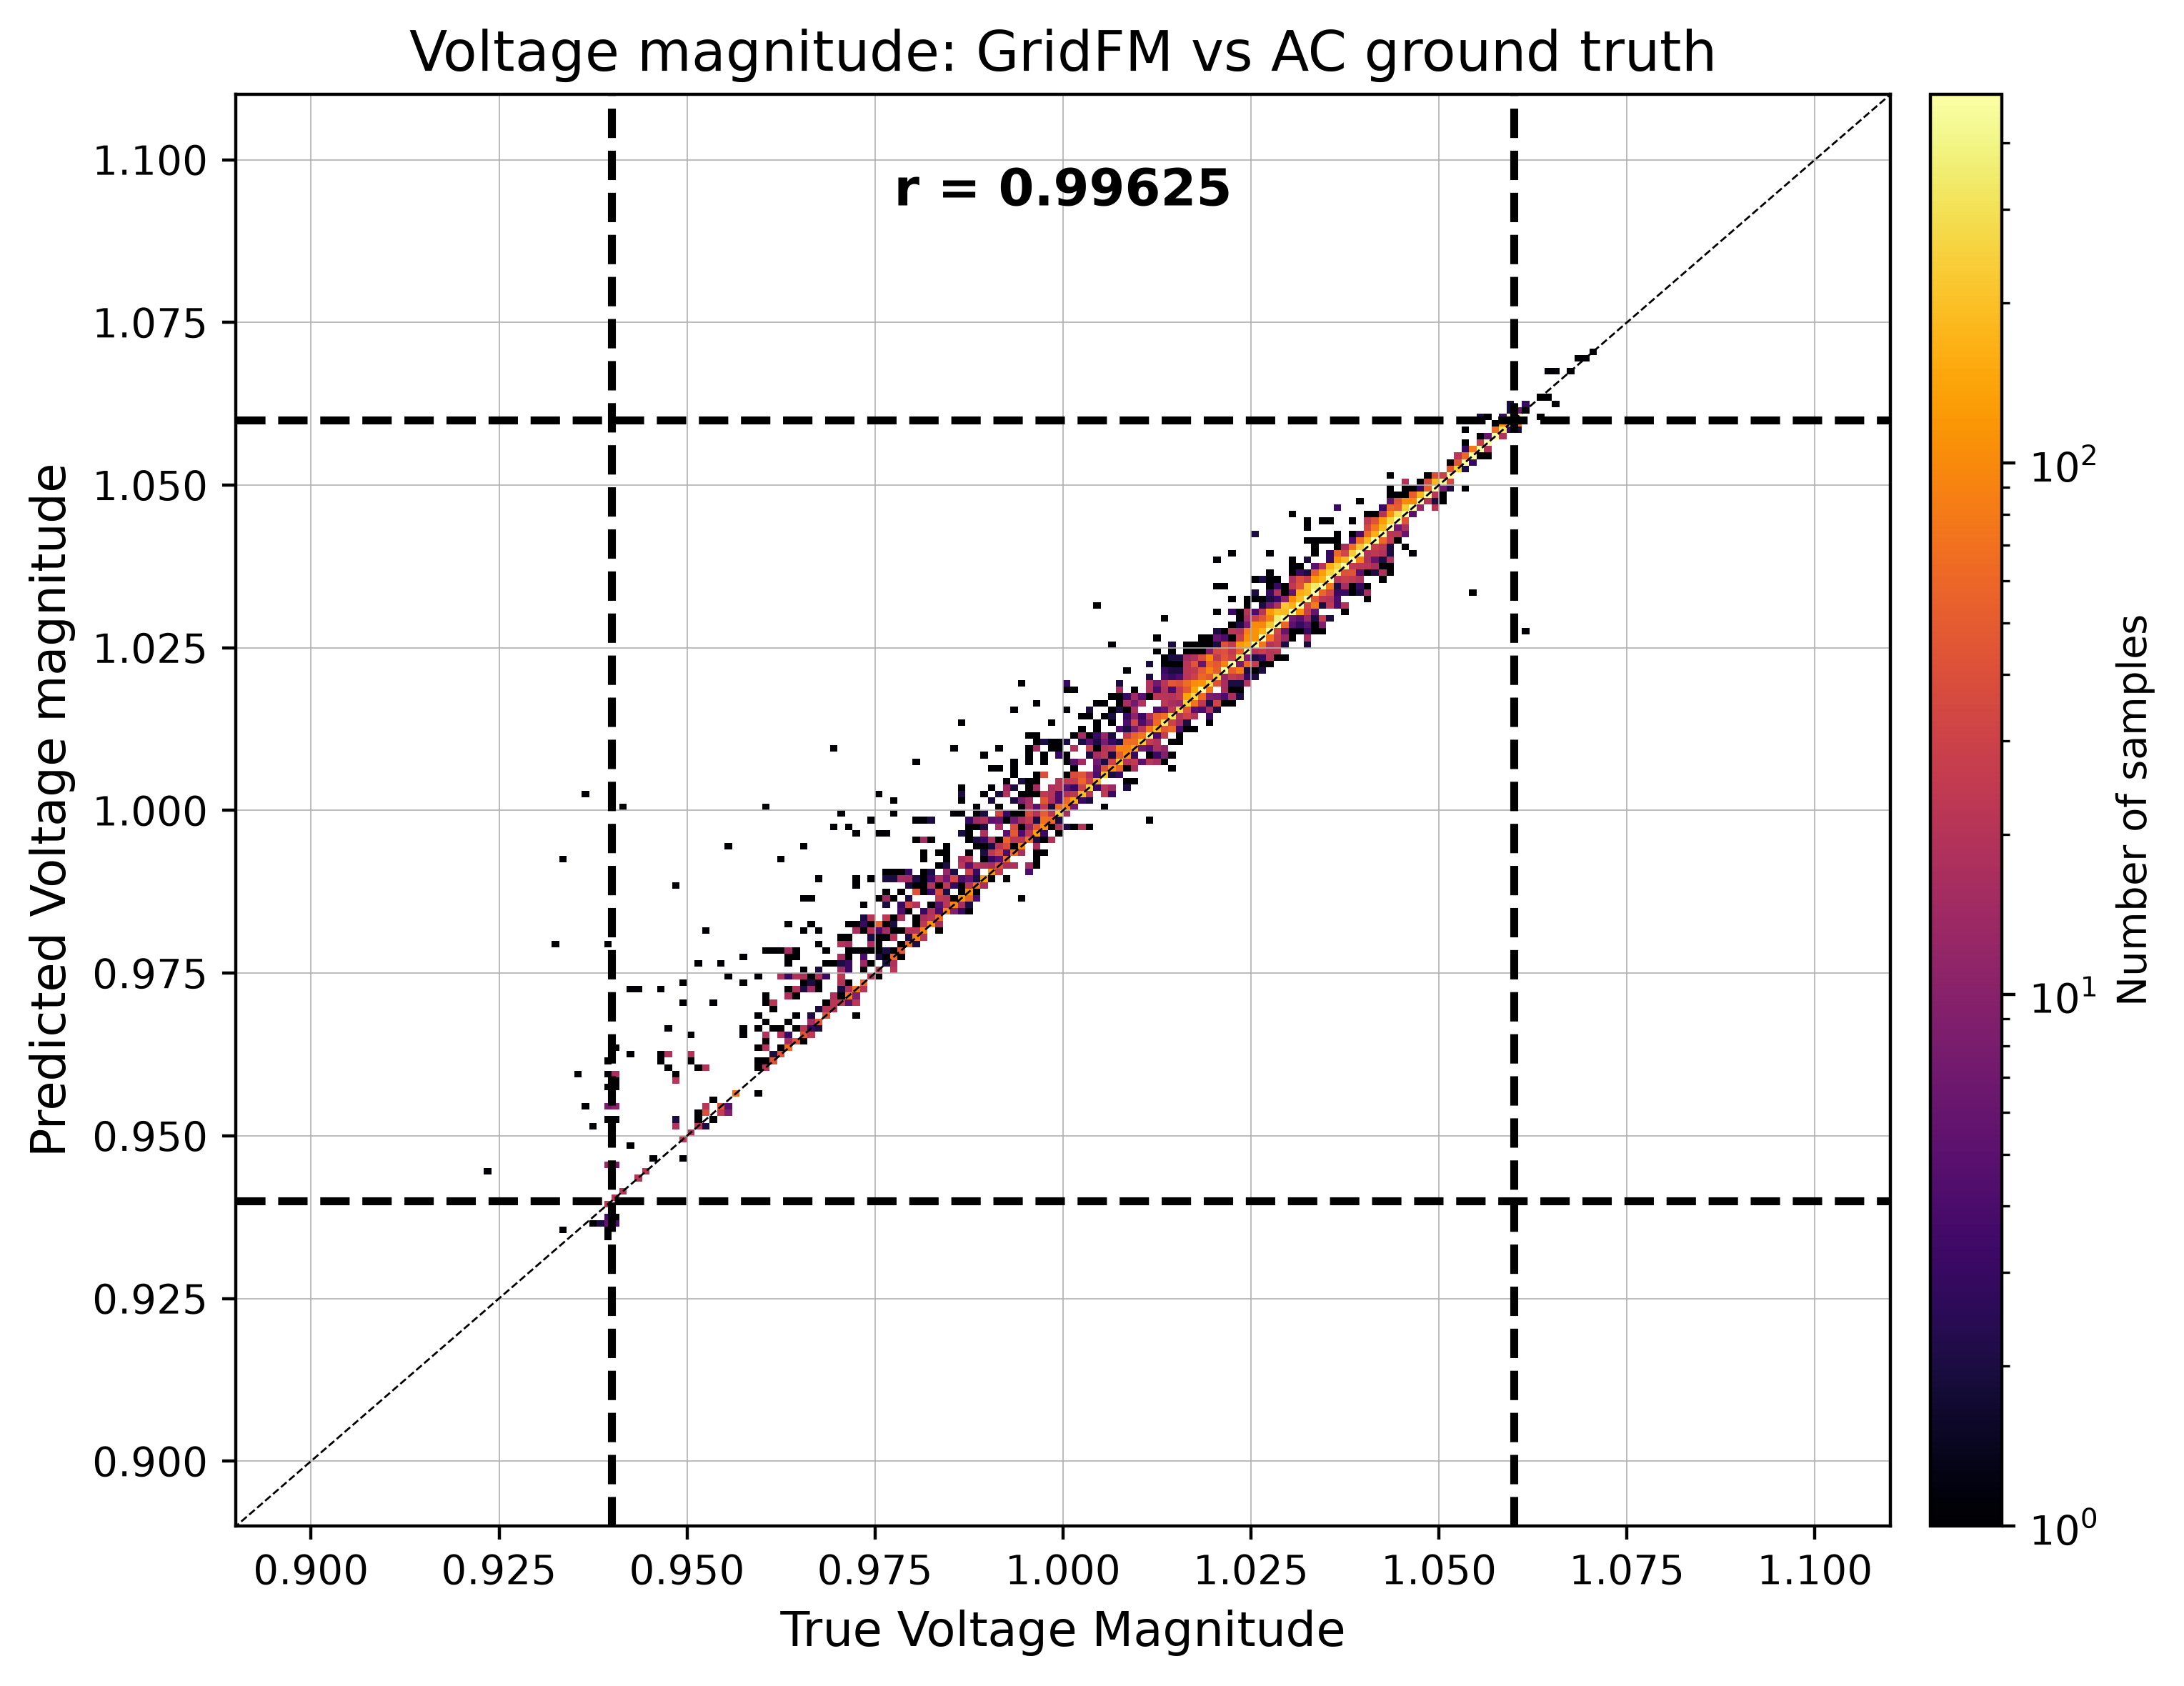

In [20]:
# x_min/x_max are offset by 0.05 because the helper draws its guide lines at +/-0.05,
# which puts them exactly on the real 0.94 / 1.06 limits.
plot_mass_correlation_density_voltage(
    pd.DataFrame({"Vm": vm_t, "Vm_pred_corrected": vm_p}),
    "gridfm",
    "Voltage magnitude: GridFM vs AC ground truth",
    x_min=0.89,
    y_min=0.89,
    x_max=1.11,
    y_max=1.11,
)

## 7. Thermal screening: line loadings under N-1

Now the harder question — line *loading*. This needs branch currents, so we go from bus voltage
phasors through the admittance matrices.

Two things matter here and are easy to get wrong:

- **The admittance matrix varies per scenario.** This dataset was generated with
  `admittance_perturbation: sigma 0.2`, so roughly 95% of branches have different `Y` in every
  scenario. `Yf`/`Yt` must be rebuilt **inside** the loop, not once outside it.
- **Out-of-service branches** have `br_status == 0` and `Y` exactly 0. All 186 branch rows are
  present in every scenario, so we mark those loadings `-1` rather than dropping rows, which keeps
  the arrays aligned with `rate_a`.

First, a correctness gate that involves no model at all: feed the **AC ground-truth** voltages
through our pipeline and check if we reproduce the branch flows shipped in the dataset. If this fails,
every loading number afterwards is meaningless regardless of how good the model is.

In [25]:
from gridfm_graphkit.datasets.postprocessing import (
    compute_branch_currents_kA,
    compute_loading,
    create_admittance_matrix,
)


def admittance(scenario):
    """Build this scenario's branch admittance matrices.

    `create_admittance_matrix(bus_params, branch_params, sn_mva)` returns four things:

      Yf, Yt        complex arrays of shape (n_branch, n_bus). `Yf @ V` is the per-unit current
                    flowing into the *from* end of every branch, `Yt @ V` the current into the
                    *to* end. They are the branch-wise counterpart of the usual bus admittance
                    matrix, and they encode line impedances, line charging and transformer taps.
                    Think of Yf as a fixed linear operator mapping bus voltages to branch
                    currents: all the network topology and physics lives in these two matrices.
      Vf_kV, Vt_kV  nominal voltage (kV) at each branch's from/to bus, needed to convert per-unit
                    currents into kA further down.

    Two contracts to respect:
      * the function expects the nominal-voltage column to be named `baseKV`, while the parquet
        calls it `vn_kv` -- hence the rename;
      * row order is positional, not keyed. Buses must be sorted by `bus` so that row i of V is
        bus i, and branches by `idx` so that row j of Yf lines up with row j of the branch table,
        and therefore with `rate_a` and `br_status`.
    """
    bs = bus_raw[bus_raw.scenario == scenario].sort_values("bus")
    bx = branch_raw[branch_raw.scenario == scenario].sort_values("idx")
    Yf, Yt, Vf_kV, Vt_kV = create_admittance_matrix(
        bs.rename(columns={"vn_kv": "baseKV"}), bx, SN_MVA
    )
    return bs, bx, Yf, Yt, Vf_kV, Vt_kV


# --- correctness gate: no model involved -------------------------------------------------------
# Push the dataset's own AC solution through our pipeline and check we recover the branch flows the
# dataset also ships (`pf`, `qf`). 20 scenarios is plenty for what is essentially an identity test.
worst = 0.0
for scenario in sorted(tbl.scenario.unique())[:20]:
    bs, bx, Yf, Yt, _, _ = admittance(scenario)
    # One complex voltage phasor per bus: magnitude in per-unit, angle rotated into the complex
    # plane. This is the standard way an AC sinusoid at fixed frequency is represented -- a single
    # complex number carrying amplitude and phase, so that Ohm's law becomes ordinary matrix algebra.
    V = bs.Vm.to_numpy() * np.exp(
        1j * np.deg2rad(bs.Va.to_numpy())
    )  # raw Va is in DEGREES
    # Complex power leaving the from-end of each branch: S = V * conj(I), evaluated at the from-bus
    # voltage, scaled from per-unit to MVA by the system base. Real part = MW (the `pf` column),
    # imaginary part = MVAr (`qf`). `bx.from_bus` indexes V, which is why bus order mattered above.
    S_from = V[bx.from_bus.to_numpy()] * np.conj(Yf @ V) * SN_MVA
    # Out-of-service branches have Y exactly 0 and pf/qf 0, so they match trivially and tell us
    # nothing; exclude them so the check is actually about the in-service physics.
    live = bx.br_status.to_numpy() == 1
    worst = max(
        worst,
        np.abs(S_from.real - bx.pf.to_numpy())[live].max(),
        np.abs(S_from.imag - bx.qf.to_numpy())[live].max(),
    )
print(f"max deviation from the dataset's own branch flows: {worst:.2e} MW/MVAr")
print(f"(branch flows reach {np.abs(branch_raw.pf).max():.0f} MW, so this is exact)")
assert worst < 1e-3, "admittance/flow pipeline disagrees with the dataset"

max deviation from the dataset's own branch flows: 1.30e-11 MW/MVAr
(branch flows reach 963 MW, so this is exact)


In [26]:
t0 = time.time()
scenarios = sorted(tbl.scenario.unique())[:N_ANALYSIS]
# Pre-group the prediction table once, sorted by bus, so the loop can look a scenario up in O(1)
# and its row order already matches the admittance matrices' bus order.
by_scenario = {s: g.sort_values("bus") for s, g in tbl.groupby("scenario")}
loadings = {"ac": [], "gridfm": [], "dc": []}
n_tripped = []

for scenario in scenarios:
    bs, bx, Yf, Yt, Vf_kV, Vt_kV = admittance(
        scenario
    )  # rebuilt every scenario -- Y varies
    live = bx.br_status.to_numpy() == 1
    rate_a = bx.rate_a.to_numpy()  # thermal rating in MVA; loading is the flow / this
    n_tripped.append(int((~live).sum()))

    vm_s, va_s = bus_voltages(by_scenario[scenario])
    # Three voltage states over the *same* network, so any difference in loading is attributable
    # to the voltages alone.
    cases = {
        # AC ground truth and the shipped DC solution store Va in DEGREES ...
        "ac": bs.Vm.to_numpy() * np.exp(1j * np.deg2rad(bs.Va.to_numpy())),
        # DC power flow assumes every voltage magnitude is exactly 1.0 p.u. and solves only for
        # angles -- that is the approximation, and it is why `Va_dc` ships but no `Vm_dc` does.
        "dc": np.ones(len(bs)) * np.exp(1j * np.deg2rad(bs.Va_dc.to_numpy())),
        # ... while the prediction table is already in RADIANS.
        "gridfm": vm_s * np.exp(1j * va_s),
    }
    for name, V in cases.items():
        # per-unit voltages -> branch currents in kA (both ends, since a line with charging
        # current does not carry the same current at each end) -> loading as a fraction of
        # rate_a, taking the worse end. 1.0 means the branch is exactly at its thermal rating.
        I_f, I_t = compute_branch_currents_kA(Yf, Yt, V, Vf_kV, Vt_kV, SN_MVA)
        loading = compute_loading(I_f, I_t, Vf_kV, Vt_kV, rate_a)
        # Keep tripped branches as rows so every array stays (n_scenario, n_branch) and aligned
        # with rate_a; -1 is a sentinel no real loading can take, filtered via `in_service` below.
        loadings[name].append(np.where(live, loading, -1.0))

L = {k: np.array(v) for k, v in loadings.items()}  # each (n_scenario, n_branch)
timings["loadings"] = time.time() - t0
in_service = L["ac"] >= 0  # boolean mask reused by every comparison from here on

# the sanity check the analysis depends on: all three cases must agree on what was tripped
for name in ("gridfm", "dc"):
    assert ((L[name] < 0) == (L["ac"] < 0)).all(), (
        f"{name} disagrees on tripped branches"
    )
print(
    f"{len(scenarios)} scenarios x {L['ac'].shape[1]} branches in {timings['loadings']:.0f}s"
)
print(
    f"tripped branches per scenario: min {min(n_tripped)}, max {max(n_tripped)}, "
    f"mean {np.mean(n_tripped):.2f}  -> this is N-1 data"
)
print("[ok] identical tripped-branch masks across AC / GridFM / DC")

200 scenarios x 186 branches in 0s
tripped branches per scenario: min 0, max 1, mean 0.79  -> this is N-1 data
[ok] identical tripped-branch masks across AC / GridFM / DC


In [27]:
print(f"{'':8s} {'loading MAE':>12s} {'max-loading corr':>18s}")
# The severity of a contingency is its *worst* branch, so reduce each scenario to one number.
# Replace the -1 sentinel with -9 first: an out-of-service branch must never win the max, and -1
# could in principle tie with nothing, so we push it clear of any real value.
peak = {k: np.where(in_service, L[k], -9).max(axis=1) for k in L}
for name in ("gridfm", "dc"):
    # MAE over every in-service branch-case: absolute accuracy, in units of "fraction of rating".
    mae = np.abs(L[name][in_service] - L["ac"][in_service]).mean()
    # Correlation of the per-scenario peak: does severity *rank* correctly, which is what
    # screening actually needs. Section 8 measures the ranking directly.
    corr = np.corrcoef(peak[name], peak["ac"])[0, 1]
    print(f"{name:8s} {mae:>12.4f} {corr:>18.4f}")
print(
    f"\ntrue loadings: mean {L['ac'][in_service].mean():.3f}, "
    f"p99 {np.percentile(L['ac'][in_service], 99):.3f}, max {L['ac'][in_service].max():.3f}"
)

          loading MAE   max-loading corr
gridfm         0.0385             0.3860
dc             0.0307             0.9039

true loadings: mean 0.264, p99 0.952, max 2.239


The DC approximation is a **strong** baseline for line loading on this network, and at this training
budget GridFM does not beat it. That is worth stating plainly rather than hiding. Section 9 shows
exactly which predicted quantity is responsible.

Overloads (`loading > 1.0`) are rare per branch but common per scenario, so we report both: the
branch-level confusion matrix, and the scenario-level screening decision an operator actually makes.

branch-level: 110 overloads in 37043 in-service branch-cases (0.297%)

Accuracy: 0.995
Confusion Matrix:
TP: 60, FP: 123, TN: 36967, FN: 50
GridFM
TPR: 0.545 (percentage of overloadings correctly predicted)
FPR: 0.003 (percentage of non-overloadings predicted as overloadings)
TNR: 1.00
FNR: 0.45


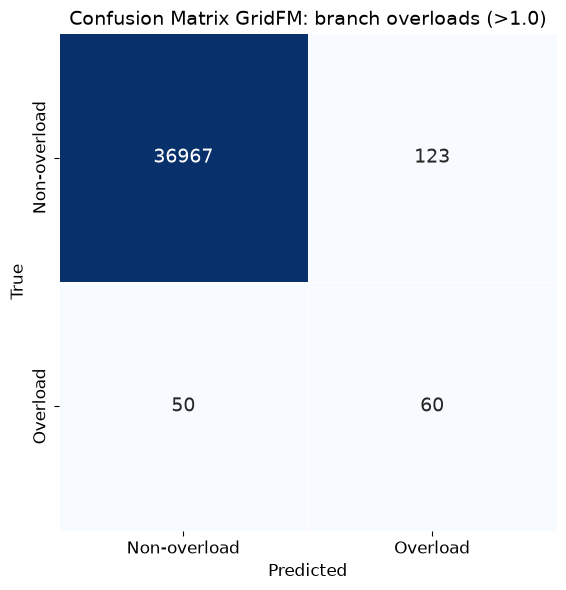


scenario-level screening (does this contingency overload anything?)
  55/200 scenarios truly contain an overload
  gridfm  recall 0.727  precision 0.381
  dc      recall 1.000  precision 0.279


In [28]:
THRESHOLD = (
    1.0  # loading > 1.0 means the branch is carrying more than its thermal rating
)
over_true = (L["ac"] > THRESHOLD) & in_service  # (n_scenario, n_branch) booleans
print(
    f"branch-level: {over_true.sum()} overloads in {in_service.sum()} in-service branch-cases "
    f"({100 * over_true.sum() / in_service.sum():.3f}%)\n"
)
over_pred = (L["gridfm"] > THRESHOLD) & in_service
# .ravel() flattens both matrices consistently, so each element is one (scenario, branch) decision.
TP, FP, TN, FN = compute_cm_metrics(
    over_true.ravel(), over_pred.ravel(), "gridfm_overload", "GridFM"
)
plot_cm(TN, FP, FN, TP, "gridfm_overload", f"GridFM: branch overloads (>{THRESHOLD})")

# The branch-level matrix is dominated by the ~99.9% of branch-cases that are fine. The decision an
# operator actually makes is per *contingency*: does this scenario need a full AC study at all? So
# collapse each row with .any() and score that instead. Recall is the number that matters -- a
# missed overload is an unstudied risk, whereas a false alarm only costs one extra AC solve.
print("\nscenario-level screening (does this contingency overload anything?)")
flagged_true = over_true.any(axis=1)
print(f"  {flagged_true.sum()}/{len(scenarios)} scenarios truly contain an overload")
for name in ("gridfm", "dc"):
    flagged = ((L[name] > THRESHOLD) & in_service).any(axis=1)
    tp = (flagged_true & flagged).sum()
    fp = (~flagged_true & flagged).sum()
    fn = (flagged_true & ~flagged).sum()
    # max(..., 1) guards the degenerate case where nothing at all was flagged.
    print(
        f"  {name:7s} recall {tp / max(tp + fn, 1):.3f}  precision {tp / max(tp + fp, 1):.3f}"
    )

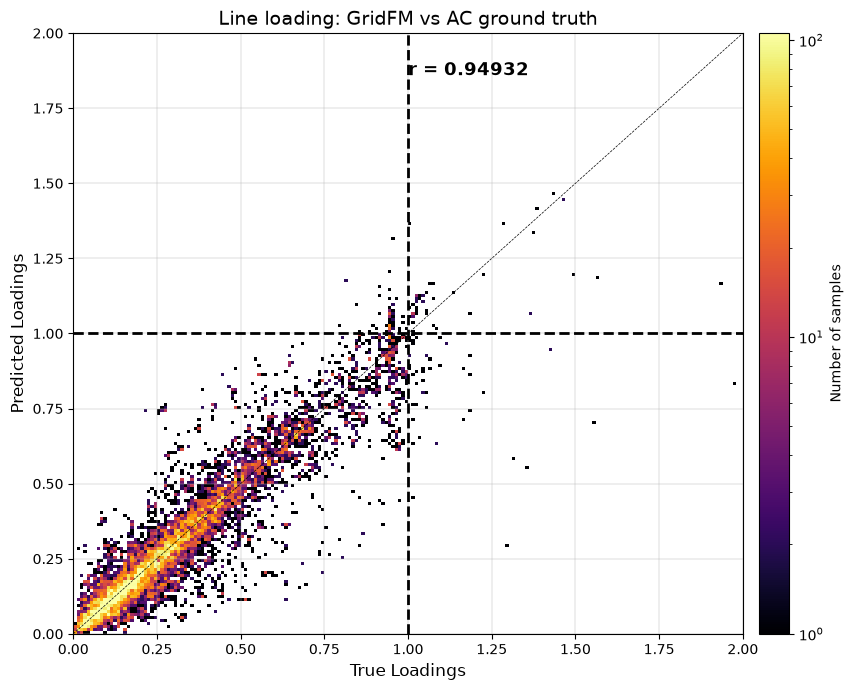

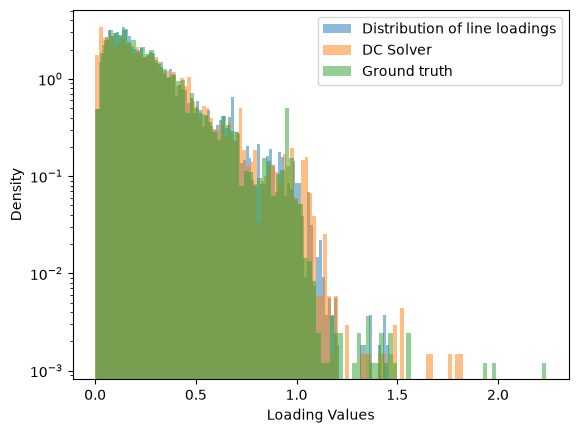

In [29]:
# Both helpers take flat arrays, so `[in_service]` collapses the (scenario, branch) matrices into
# 1-D and drops the -1 sentinels in one step. They write PNGs into the CWD (now ARTIFACTS).
#
# Density scatter of predicted vs true loading -- the diagonal is perfection, and capping the axes
# at 2.0 keeps the interesting region around the 1.0 overload threshold readable.
plot_mass_correlation_density(
    L["ac"][in_service],
    L["gridfm"][in_service],
    "gridfm_loading",
    "Line loading: GridFM vs AC ground truth",
    x_max=2,
    y_max=2,
)
# Three overlaid histograms. Distributions can match well while individual branches are wrong, so
# read this as a check for systematic bias (a shifted or over-narrow distribution), not accuracy.
plot_loading_predictions(
    L["gridfm"][in_service],
    L["dc"][in_service],
    L["ac"][in_service],
    "gridfm",
    "Distribution of line loadings",
)

## 8. Ranking contingencies

Screening is often used to *rank* rather than to give absolute numbers: run every contingency, sort
by severity, hand the worst few to a full AC study. Ranking tolerates absolute error as long as the
order survives, so it is a fairer test of a surrogate than MAE.

In [30]:
# argsort(-x) gives indices from largest to smallest, so order_true[:k] is the k scenarios the AC
# solver considers most severe. We then ask how many of those each surrogate also puts in its own
# top k -- a set overlap, so it only rewards getting the *membership* of the shortlist right, not
# the exact order within it and not the absolute loading values.
order_true = np.argsort(-peak["ac"])
for k in (10, 20, 50):
    top_true = set(order_true[:k].tolist())
    hits = {
        n: len(top_true & set(np.argsort(-peak[n])[:k].tolist()))
        for n in ("gridfm", "dc")
    }
    # Chance level is roughly k*k/n_scenarios, so k=20 out of 200 would give ~2/20 at random.
    print(
        f"top-{k:<3d} riskiest contingencies recovered:  "
        f"GridFM {hits['gridfm']:>2d}/{k}   DC {hits['dc']:>2d}/{k}"
    )

top-10  riskiest contingencies recovered:  GridFM  5/10   DC 10/10
top-20  riskiest contingencies recovered:  GridFM  9/20   DC 17/20
top-50  riskiest contingencies recovered:  GridFM 30/50   DC 26/50


## 9. Why the loadings lag: it is the angle, not the magnitude

A useful diagnostic: recompute the loadings twice more, each time replacing **one** predicted
quantity with ground truth. Whichever substitution repairs the result identifies the bottleneck.

In [31]:
# Same loop as section 7, but each pass builds a *hybrid* voltage state: one predicted quantity and
# one ground-truth quantity. Nothing is retrained -- this is an ablation of the inputs to the physics,
# which is the cheapest way to find out which half of the model's output is limiting the result.
diag = {"vm_only": [], "va_only": []}
for scenario in scenarios:
    bs, bx, Yf, Yt, Vf_kV, Vt_kV = admittance(scenario)
    live = bx.br_status.to_numpy() == 1
    rate_a = bx.rate_a.to_numpy()
    vm_s, va_s = bus_voltages(by_scenario[scenario])  # predicted (clamped where known)
    vm_t = bs.Vm.to_numpy()  # true magnitudes, per-unit
    va_t = np.deg2rad(bs.Va.to_numpy())  # true angles, DEGREES -> radians
    for name, V in (
        ("vm_only", vm_s * np.exp(1j * va_t)),  # predicted Vm, TRUE Va
        ("va_only", vm_t * np.exp(1j * va_s)),
    ):  # TRUE Vm, predicted Va
        I_f, I_t = compute_branch_currents_kA(Yf, Yt, V, Vf_kV, Vt_kV, SN_MVA)
        diag[name].append(
            np.where(live, compute_loading(I_f, I_t, Vf_kV, Vt_kV, rate_a), -1.0)
        )
D = {k: np.array(v) for k, v in diag.items()}

# Read this table by comparing each row against the first. Whichever substitution moves the numbers
# is the quantity that was holding the result back.
print(f"{'voltages used':28s} {'loading MAE':>12s} {'max-loading corr':>18s}")
rows = [
    ("predicted Vm + predicted Va", L["gridfm"]),
    ("predicted Vm + TRUE Va", D["vm_only"]),
    ("TRUE Vm + predicted Va", D["va_only"]),
]
for label, arr in rows:
    mae = np.abs(arr[in_service] - L["ac"][in_service]).mean()
    corr = np.corrcoef(np.where(in_service, arr, -9).max(axis=1), peak["ac"])[0, 1]
    print(f"{label:28s} {mae:>12.4f} {corr:>18.4f}")

voltages used                 loading MAE   max-loading corr
predicted Vm + predicted Va        0.0385             0.3860
predicted Vm + TRUE Va             0.0022             0.9999
TRUE Vm + predicted Va             0.0380             0.3866


Supplying the true angles collapses the error and pushes the ranking correlation to ~1.0, while
supplying the true magnitudes changes almost nothing. **Voltage magnitude is essentially solved;
the residual angle error is the whole story.**

That is not a loss-weighting artifact. `MaskedBusMSE` pools Vm and Va into a single MSE, and the
normalizer leaves Vm in p.u. (std ~0.03) while converting Va to radians (std ~0.25) — so the angle
already dominates the objective by roughly 70x in variance. Angle is simply the harder target: it is
a *global* quantity fixed only by the reference bus, so information has to propagate across the whole
network, and 12 message-passing layers is marginal for a 118-bus graph whose diameter is comparable. More training (the loss was
still falling) and more layers are the levers, and both cost wall-clock we deliberately did not spend.

## 10. Speed

The honest comparison. We time the model forward pass with batches already resident on the device,
against the AC solver time recorded in the dataset's own `runtime_data.parquet` (4.3 ms/scenario).
Those solver timings come from the generating machine, so treat this as indicative.

In [32]:
AC_SOLVE_MS = (
    4.3  # measured per-scenario AC power flow, from the dataset's runtime_data.parquet
)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = task.model.to(device).eval()  # .to() because Lightning may have left it on CPU
# Move every batch onto the device up front. Dataloading and host->device transfer are real costs in
# production, but they are not what an AC solver does, so including them would compare two different
# things. What we time is the arithmetic; the print-out says what was excluded.
batches = [b.to(device) for b in DataLoader(datamodule.test_datasets[0], batch_size=64)]
n = sum(b.num_graphs for b in batches)  # graphs, i.e. scenarios, not buses

with torch.no_grad():
    for b in batches[:2]:
        model(b)  # warm up: first calls pay MPS kernel compilation
    # MPS queues work asynchronously, so without synchronize() we would time the enqueue, not the
    # compute -- an easy way to "measure" an impossibly fast model.
    if device.type == "mps":
        torch.mps.synchronize()
    t0 = time.time()
    for b in batches:
        model(b)
    if device.type == "mps":
        torch.mps.synchronize()
    elapsed = time.time() - t0

ms = 1000 * elapsed / n
print(
    f"GridFM forward: {ms:.2f} ms/scenario ({n / elapsed:.0f} scenarios/s, batch 64, {device.type})"
)
print(
    f"AC solver:      {AC_SOLVE_MS} ms/scenario  ->  {AC_SOLVE_MS / ms:.1f}x speed-up"
)
print(
    "\nA modest margin, because AC power flow on a 118-bus network is already fast. Two runs"
    "\nof this cell on the same laptop gave 1.9 and 3.3 ms/scenario, i.e. 2.2x and 1.3x, so"
    "\ndo not read the exact ratio as a property of the model -- at this scale it is mostly a"
    "\nproperty of how busy the machine is. The surrogate argument is much stronger for optimal"
    "\npower flow, where the same dataset family records 157 ms per AC OPF solve - see the OPF"
    "\ntutorial notebook."
)

GridFM forward: 2.28 ms/scenario (438 scenarios/s, batch 64, mps)
AC solver:      4.3 ms/scenario  ->  1.9x speed-up

A modest margin, because AC power flow on a 118-bus network is already fast. Two runs
of this cell on the same laptop gave 1.9 and 3.3 ms/scenario, i.e. 2.2x and 1.3x, so
do not read the exact ratio as a property of the model -- at this scale it is mostly a
property of how busy the machine is. The surrogate argument is much stronger for optimal
power flow, where the same dataset family records 157 ms per AC OPF solve - see the OPF
tutorial notebook.


In [33]:
os.chdir(REPO / "examples" / "notebooks")  # undo the earlier chdir
# Sum of the phases we instrumented, not true wall clock -- it excludes the untrained baseline pass
# and the plotting, so expect the notebook to feel a minute or so longer than this total.
timings["total"] = sum(v for k, v in timings.items() if k != "total")
for k, v in timings.items():
    print(f"{k:10s} {v:7.1f}s")
print(f"\nplots and logs written to {ARTIFACTS}")

slice          0.0s
setup          0.1s
train        440.5s
predict        1.8s
loadings       0.2s
total        442.5s

plots and logs written to /Users/pao/Documents/IBM/gridfm-graphkit/data/nb_out_pf


## Summary

Ranges are the spread over two runs of this notebook at this exact config. MPS kernels are not
bit-deterministic, so `seed: 0` pins the data split and the initialisation but not the arithmetic.

| | result |
|---|---|
| Voltage magnitude, masked buses | RMSE 0.0028–0.0035 p.u. — essentially solved (~120x better than untrained) |
| Voltage-violation screening | F1 0.84–0.85 at the 0.94–1.06 p.u. band |
| Line-loading MAE | 0.047–0.048 vs 0.031 for DC — **DC wins at this budget** |
| Contingency ranking (top-20) | GridFM 6–10 / 20 vs DC 17 / 20 |
| Scenario overload recall | 0.67–0.82 (precision 0.29–0.32) |
| Bottleneck | residual 5–7 degree angle error, isolated in section 9 |
| Speed | 1.3–2.2x vs AC power flow (1.9–3.3 ms vs 4.3 ms per scenario) |
| Total runtime | 9–11.5 minutes on an M-series laptop (30–44 s/epoch) |

Two of those ranges are wide, for different reasons, and both are worth a sentence. The **screening
metrics** (top-20 recovery, scenario recall) move because they are thresholded counts over 200 test
scenarios holding only ~110 genuinely overloaded branch-cases, so a handful of borderline cases
crossing the line shifts the fraction visibly. Read them as "GridFM ranks thermal contingencies
poorly, DC ranks them well" — that ordering is stable — rather than as specific numbers. The
**speed** figure moves with machine load and thermal state rather than with the model, and at 1–2x
there is no real margin to defend anyway; see section 10.

Two runs is not many, either. The qualitative conclusions here survive a re-run; the individual
figures do not, and a third run would not make them do so.

**What to take away.** A ~10-minute model on a laptop learns voltage magnitudes well enough to screen
voltage violations usefully, but not angles well enough to rank thermal contingencies — and the
diagnostic in section 9 tells you that unambiguously instead of leaving you to guess. That is the
point of the notebook: it shows you how to interrogate a surrogate, not just how to train one.

To do better, spend the wall-clock we did not: raise `training.epochs` (validation loss was still
falling), increase `model.num_layers` so angle information can propagate further, and train on more
than 5,000 of the available 219,103 scenarios. The same pipeline scales without modification — only
the config changes.

The companion notebook, `Tutorial_opf_surrogate_case118.ipynb`, runs the same pipeline on **optimal**
power flow. It is worth reading next for the contrast: OPF needs ~50 epochs rather than 15 before
repeated runs agree even on the *sign* of its headline metric, and the speed-up against the AC solver
is ~82x rather than the 1–2x here.